In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl


from pathlib import Path
import scipy
import numpy as np
import pandas as pd
import datetime as dt
import soundfile as sf
import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [2]:
import UBNA_localize_process_GCC__20250505 as localize

In [3]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [4]:
GRID_SIZE = 40
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

FS = 250000
ASSUMED_BAT_SPEED = 4 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

In [5]:
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
UBNA_ARRAY_MIC_LOCS =  (254/10000) * np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])
UBNA_ARRAY_MIC_LOCS

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625],
       [ 0.       ,  0.       ,  0.       ]])

In [6]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 7
MICROPHONES_USED = np.array([1,2,3,4,5,6,7,8])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

In [7]:
%matplotlib inline

file_dir = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array')
site_key = 'Carp'
freq_key = ''

In [8]:
start_stop_file = (file_dir / 'Start_Stop_Times.txt')
with open(start_stop_file, "r", encoding="utf-8") as file:
    content = file.read()
    print(content)
    
start_stop_arr = content.split('\n')
start_of_session = start_stop_arr[0]
FILE_DATETIME = dt.datetime.strptime(start_of_session, 'Start time: %H:%M:%S %m/%d/%y UTC')

Start time: 03:30:14 05/02/25 UTC
Stop time: 04:38:26 05/02/25 UTC



In [9]:
FILE_DURATION = 600
HOUR_TAG = 'hour_0'

In [10]:
file_offset = 1800
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name
channel_dets = localize.get_dets_observed_from_all_channels(file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']

In [11]:
removed_overlaps = pd.read_csv(f'ARRAY_20250501_{dir_name}_OVERLAPS_REMOVED.csv')
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()

In [12]:
def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    file_offset = audio_features['file_offset']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - (start+file_offset))*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=localize.FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        plt.axvline(x=(row['peak_frequency_time_SPECTROGRAM'] - start)*(fs/2), color='w', linestyle='dashed')
        plt.text(x=(row['start_time'] - (start+file_offset))*(fs/2), y=row['low_freq']/(fs/2), s=f"{round(row['SNR'], 2)}dB"
                 , color='w', fontsize=8, fontweight='bold')
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace((start+file_offset), (start+file_offset)+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_bout(write_file, selected_channel_for_ref, start, length, file_offset, subset1, subset2):
    recorded_audio = sf.SoundFile(write_file)
    recorded_audio.seek(int(FS*start))
    audio_seg = recorded_audio.read(int(FS*length))
    highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, FS, 20000)

    print(f'Currently at {write_file}')
    audio_features = dict()
    audio_features['figsize'] = (15, 3)
    audio_features['file_path'] = write_file
    audio_features['audio_seg'] = highpassed_audio_seg
    audio_features['sample_rate'] = FS
    audio_features['start'] = start
    audio_features['file_offset'] = file_offset
    audio_features['duration'] = length

    spec_features = dict()
    spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -90
    spec_features['vmax'] = 0

    audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel_for_ref+1})"
    plot_colored_dets_over_audio(audio_features, spec_features, pd.DataFrame())
    plot_colored_dets_over_audio(audio_features, spec_features, subset1)
    plot_colored_dets_over_audio(audio_features, spec_features, subset2)

Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array/hour_0_1800to2400/hour_0_channel7_1800to2400.WAV


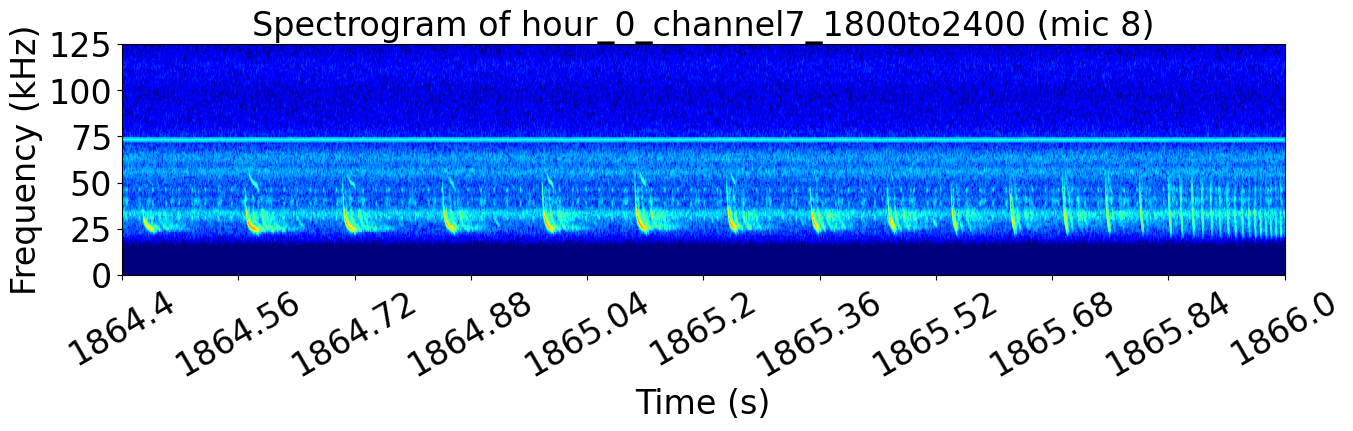

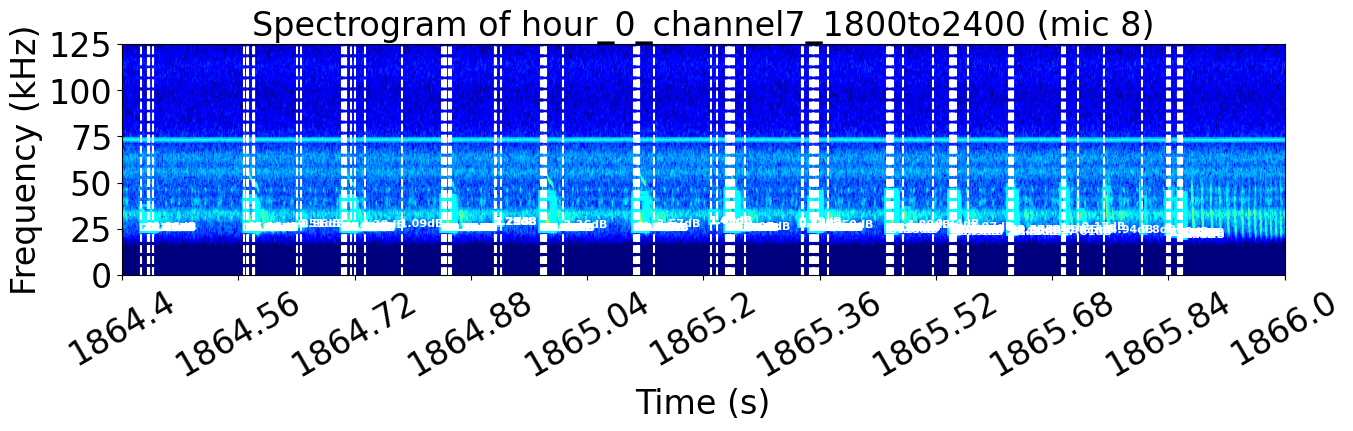

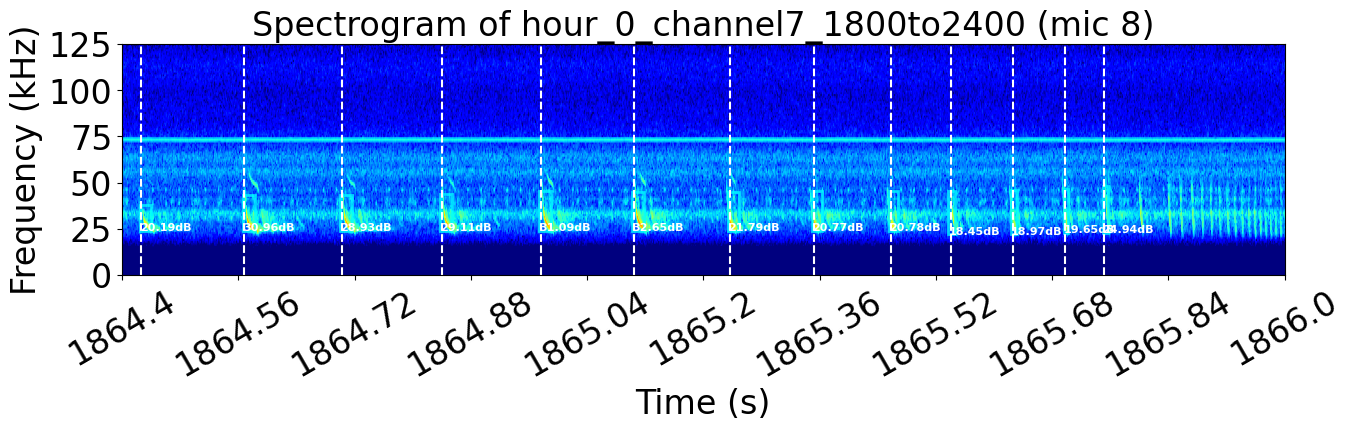

In [13]:
%matplotlib inline

write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

start = 64.4
length = 1.6
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=15].reset_index(drop=True).copy()
plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

In [14]:
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SPEC_NFFT = 32

In [15]:
def extract_call_starts_for_call(call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(approx_call_dur+0.002))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    return found_call_start, found_call_dur

def snr_quality_metric(snrcb, snreb, snrce):
    return abs((snrcb+snreb)/(snrce))

In [ ]:
%matplotlib inline

example_calls = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS, int(FS*SNR_CALC_LENGTH)), dtype=np.float64)
example_call_snrs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
example_snr_facs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
example_det_durs = np.zeros(set_for_tdoa.shape[0], dtype=np.float64)
examining_df = set_for_tdoa[::].copy()
for channel_num in (MICROPHONES_USED-1):
    for i, det in examining_df.iterrows():
        start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
        approx_call_dur = localize.get_approx_call_dur(det)
        example_det_durs[i] = approx_call_dur

        write_file = write_dir / f'{HOUR_TAG}_channel{channel_num}_{FILE_TIME_TAG}.WAV'
        
        filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)
        example_calls[i, channel_num,:] = filtered_det

        found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
        found_call_end = (found_call_start+found_call_dur)
        echo_pad = int(FS*TIME_PAD_FOR_ECHO)
        found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                found_call_start, 
                                                                                                found_call_dur)
        snrce = localize.get_snr_from_band_limited_signal(found_call, found_echo)
        snrcb = localize.get_snr_from_band_limited_signal(found_call, found_background)
        snreb = localize.get_snr_from_band_limited_signal(found_echo, found_background)
        example_call_snrs[i, channel_num] = snrcb
        example_snr_facs[i, channel_num] = snr_quality_metric(snrcb, snreb, snrce)

In [17]:
def extract_reference_call_only(ref_call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(ref_call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(0.008))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only, found_call_start/FS, found_call_dur/FS

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:], np.argmax(feature[detection_index])

TEMPLATE_CHANNEL = 3
def index_reference_call_based_on_channel(calls, detection_index, channel):
    return calls[detection_index, channel,:], channel

In [ ]:
def simulate_N_receivers(time_step, template_channel):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

    example_calls = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS, int(FS*SNR_CALC_LENGTH)), dtype=np.float64)
    example_call_snrs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    example_snr_facs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    example_det_durs = np.zeros(set_for_tdoa.shape[0], dtype=np.float64)
    examining_df = set_for_tdoa[::].copy()
    for channel_num in (MICROPHONES_USED-1):
        for i, det in examining_df.iterrows():
            start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
            approx_call_dur = localize.get_approx_call_dur(det)
            example_det_durs[i] = approx_call_dur

            write_file = write_dir / f'{HOUR_TAG}_channel{channel_num}_{FILE_TIME_TAG}.WAV'
            
            filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)
            example_calls[i, channel_num,:] = filtered_det

            found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            echo_pad = int(FS*TIME_PAD_FOR_ECHO)
            found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                    found_call_start, 
                                                                                                    found_call_dur)
            snrce = localize.get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = localize.get_snr_from_band_limited_signal(found_call, found_background)
            snreb = localize.get_snr_from_band_limited_signal(found_echo, found_background)
            example_call_snrs[i, channel_num] = snrcb
            example_snr_facs[i, channel_num] = snr_quality_metric(snrcb, snreb, snrce)
    
    example_t_delays_wrt_selected_channel = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(set_for_tdoa.shape[0]):
            nonref_dets = example_calls[det_num]
            approx_call_dur = example_det_durs[det_num]
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, template_channel)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_step]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE / 4)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE / 4)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)

    valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]
    norm = plt.Normalize(vmin=0, vmax=valid_source_locs.shape[1])
    for i in range(valid_source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(valid_source_locs[0,i], valid_source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(valid_source_locs[0,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(valid_source_locs[1,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
    
    map_ax_2d_xy.plot(valid_source_locs[0,:], valid_source_locs[1,:], color='k', alpha=0.5, zorder=1)
    map_ax_2d_xz.plot(valid_source_locs[0,:], valid_source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_2d_yz.plot(valid_source_locs[1,:], valid_source_locs[2,:], color='k', alpha=0.5, zorder=1)

    plt.show()

time_slider = widgets.IntSlider(
    value=0, min=0, max=set_for_tdoa.shape[0], step=1, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=0, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, template_channel=template_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=0, description='Time (k)', layout=Layout(width='1000px'), max=13, style=…

In [ ]:
def simulate_N_receivers(time_step, template_channel, elevation, azim):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

    example_calls = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS, int(FS*SNR_CALC_LENGTH)), dtype=np.float64)
    example_call_snrs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    example_snr_facs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    example_det_durs = np.zeros(set_for_tdoa.shape[0], dtype=np.float64)
    examining_df = set_for_tdoa[::].copy()
    for channel_num in (MICROPHONES_USED-1):
        for i, det in examining_df.iterrows():
            start = det['start_time'] - file_offset - SNR_OFFSET_BEFORE_CALL
            approx_call_dur = localize.get_approx_call_dur(det)
            example_det_durs[i] = approx_call_dur

            write_file = write_dir / f'{HOUR_TAG}_channel{channel_num}_{FILE_TIME_TAG}.WAV'
            
            filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)
            example_calls[i, channel_num,:] = filtered_det

            found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
            found_call_end = (found_call_start+found_call_dur)
            echo_pad = int(FS*TIME_PAD_FOR_ECHO)
            found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                    found_call_start, 
                                                                                                    found_call_dur)
            snrce = localize.get_snr_from_band_limited_signal(found_call, found_echo)
            snrcb = localize.get_snr_from_band_limited_signal(found_call, found_background)
            snreb = localize.get_snr_from_band_limited_signal(found_echo, found_background)
            example_call_snrs[i, channel_num] = snrcb
            example_snr_facs[i, channel_num] = snr_quality_metric(snrcb, snreb, snrce)

    example_t_delays_wrt_selected_channel = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(set_for_tdoa.shape[0]):
            nonref_dets = example_calls[det_num]
            approx_call_dur = example_det_durs[det_num]
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, template_channel)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_step]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
    norm = plt.Normalize(vmin=0, vmax=measured_d_mics_to_ref.shape[0])
    for i in range(measured_d_mics_to_ref.shape[0]):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_3d.scatter(source_locs[0,i], source_locs[1,i], 
                          source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        
    valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]
    map_ax_3d.plot(valid_source_locs[0,:], valid_source_locs[1,:], valid_source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_3d.set_xlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')
    map_ax_3d.view_init(elev=elevation, azim=azim)

    plt.show()

time_slider = widgets.IntSlider(
    value=0, min=0, max=set_for_tdoa.shape[0], step=1, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=0, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=0, description='Time (k)', layout=Layout(width='1000px'), max=13, style=…